# 02b. Feature Engineering v4: энергетические метрики и сегментация фаз полёта

**Вход:** `european_flights_clean_v3.parquet` (149M строк, 29 788 рейсов, 21 колонка
— включая 7 DQ-флагов из 02_preprocessing_v3)
**Выход:** `european_flights_enriched_v4.parquet` (149M строк, 33 колонки)

**Источники:**
- [1] Kumar et al. (2021) — Specific Total Energy, gate-based features
- [2] Aerospace (2023) — Normalized Energy Factor, energy corridors
- [4] Proud (2020) — Fuzzy logic flight phase identification

## Что изменилось vs v3

**Главный фикс (physical-domain refinement):** `specific_energy` и
`energy_ratio` теперь используют `potential = max(alt_m, 0)` вместо
сырого `alt_m`. Диагностика v3 показала, что для точек с altitude < 0
(низкие аэропорты, ADS-B noise около sea level) формула давала
heavy-tailed outliers в `energy_ratio` (max 151 при ожидаемом ≤ 1),
сосредоточенные в landing-фазе (94.8% всех outliers).

В v4 negative altitude больше не уходит в негативную потенциальную
энергию: ниже sea level reference уровень фиксируется на 0.
Это physically-correct convention для transportation aviation:
самолёт не аккумулирует энергию при погружении ниже sea level — это
просто географический reference. После фикса `energy_ratio ∈ [0, 1]`
по построению, через `np.where(denom > 0, ratio, np.nan)` + `clip(0, 1)`.

`energy_rate` пересчитывается автоматически через wide differencing
от нового `specific_energy`. Phase norms и corridors также
пересчитываются с нового baseline.

**Выходной артефакт `enriched_v4.parquet` заменяет `enriched_v3.parquet`.**
Старый файл с broken energy_ratio удаляется перед запуском Pass 2.

## Что изменилось vs v2 (контекст)

1. **Input/output** обновлены под clean_v3 / enriched_v4 версионную цепочку.
2. **Train flights определяются по flight_start_time**, а не по chunk index.
3. **Phase norms на flight-stratified выборке из всех train рейсов**
   (≤500 точек на рейс), с исключением hard-DQ точек.
4. **`MAD = 0` fallback** в robust_mean_std — устраняет NaN в
   `vertical_rate_phase_z` для cruise.
5. **Все 7 DQ-флагов** проброшены через 02b в финальный parquet.
6. **Phase transition flag** — диагностическая колонка для
   интерпретации скачков energy_deviation на границах фаз.
7. **Явные `MODEL_FEATURES_V3` и `DIAGNOSTIC_COLUMNS_V3`** — контракт
   между 02b и 03_models.
8. **Streaming merge** через ParquetWriter — без удержания всего
   датасета в RAM.

## Пайплайн

1. Identify train flights (по flight_start_time)
2. Pass 1: stratified train sample → phase norms (clean DQ excluded)
3. Pass 2: enrich (energy + phases + z-scores + transition) and save chunks
4. Merge chunks → enriched_v4.parquet (streaming via ParquetWriter)
5. Quality check (disk-based, including v4 energy_ratio constraints)
6. Visualizations
7. Declare MODEL_FEATURES_V3 / DIAGNOSTIC_COLUMNS_V3

## 1. Setup & Load

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12})

DATA_DIR = '/content/drive/MyDrive/thesis_processed'
OUTPUT_DIR = DATA_DIR

INPUT_PATH = os.path.join(DATA_DIR, 'european_flights_clean_v3.parquet')
OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'european_flights_enriched_v4.parquet')

print(f'Input:  {INPUT_PATH}')
print(f'Output: {OUTPUT_PATH}')
print(f'Input exists: {os.path.exists(INPUT_PATH)}')
print(f'Input size: {os.path.getsize(INPUT_PATH) / 1e9:.2f} GB')

Mounted at /content/drive
Input:  /content/drive/MyDrive/thesis_processed/european_flights_clean_v3.parquet
Output: /content/drive/MyDrive/thesis_processed/european_flights_enriched_v4.parquet
Input exists: True
Input size: 6.26 GB


In [2]:
# DQ flags from 02_preprocessing_v3 — to propagate without modification
DQ_FLAGS_V3 = [
    'altitude_threshold_bad',
    'groundspeed_threshold_bad',
    'vertical_rate_threshold_bad',
    'altitude_spike_corrected',
    'groundspeed_spike_corrected',
    'vertical_rate_spike_corrected',
    'stale_altitude',
]

# Hard DQ flags — point excluded from phase norm calculation
# stale_altitude и threshold_bad — physical/decoding artifacts, не нормальное поведение
# spike_corrected НЕ в hard list: значения уже исправлены валидацией с двух сторон
DQ_HARD_FOR_NORMS = [
    'altitude_threshold_bad',
    'groundspeed_threshold_bad',
    'vertical_rate_threshold_bad',
    'stale_altitude',
]

# Train/test split
TRAIN_END = pd.Timestamp('2022-11-10 23:59:59', tz='UTC')

# Stratified sampling: max points per train flight for phase norms
SAMPLE_POINTS_PER_FLIGHT = 500

# Reproducibility
RANDOM_STATE = 1321

print('Setup complete.')

Setup complete.


## 2. Identify train flights

Train flight = рейс, чей **первый** timestamp ≤ TRAIN_END.

Используем `flight_start_time`, а не «любая точка ≤ TRAIN_END», чтобы рейс
целиком относился либо к train, либо к test. Иначе один рейс мог бы быть
разрезан между двумя split'ами, что ломает per-flight аналитику и
согласованность с 03_models.

In [3]:
print('Determining train flights via flight_start_time...')
t0 = time.time()

# Лёгкий проход: только flight_id и timestamp
ts_table = pq.read_table(INPUT_PATH, columns=['flight_id', 'timestamp']).to_pandas()
ts_table['timestamp'] = pd.to_datetime(ts_table['timestamp'])

flight_starts = ts_table.groupby('flight_id')['timestamp'].min()
train_flights_set = set(flight_starts[flight_starts <= TRAIN_END].index)
test_flights_set = set(flight_starts[flight_starts > TRAIN_END].index)

n_total = len(flight_starts)
n_train = len(train_flights_set)
n_test = len(test_flights_set)

print(f'Total flights:  {n_total:,}')
print(f'Train (start ≤ {TRAIN_END.date()}): {n_train:,} ({n_train / n_total * 100:.1f}%)')
print(f'Test:           {n_test:,} ({n_test / n_total * 100:.1f}%)')
print(f'({time.time() - t0:.0f}s)')

# Build chunks for processing — by all flight_ids, not by train/test
all_flights = np.array(sorted(flight_starts.index))
CHUNK_SIZE = 3000
flight_chunks = [all_flights[i:i + CHUNK_SIZE] for i in range(0, len(all_flights), CHUNK_SIZE)]
print(f'Processing chunks: {len(flight_chunks)} (target {CHUNK_SIZE} flights each)')

del ts_table, flight_starts, all_flights
gc.collect()

Determining train flights via flight_start_time...
Total flights:  29,788
Train (start ≤ 2022-11-10): 21,537 (72.3%)
Test:           8,251 (27.7%)
(81s)
Processing chunks: 10 (target 3000 flights each)


0

## 3. Constants & functions

Robust statistics, phase classification, и core enrichment функция.

In [4]:
G = 9.81
FT_TO_M = 0.3048
KTS_TO_MS = 0.5144
DIFF_N = 5

PHASE_NAMES = {-1: 'unknown', 0: 'ground', 1: 'takeoff', 2: 'climb', 3: 'cruise',
               4: 'descent', 5: 'approach', 6: 'landing'}

PHASE_RELATIVE_COLS = ['altitude', 'groundspeed', 'vertical_rate',
                       'specific_energy', 'energy_rate']

In [5]:
def robust_mean_std(vals):
    """Robust mean/std с fallback при MAD = 0.

    Trimming median ± 5*MAD устраняет влияние выбросов. Если MAD = 0
    (например, vertical_rate в cruise — много дискретных нулей),
    trimming условие схлопывается в пустое множество. В этом случае
    fallback на полную выборку без trimming.

    Возвращает (mean, std). std = NaN, если std=0 или невалидный
    (это сигнал downstream, что z-score для этой фазы/канала
    не может быть вычислен).
    """
    vals = pd.Series(vals).dropna()
    if len(vals) < 100:
        return np.nan, np.nan

    med = vals.median()
    mad = np.median(np.abs(vals - med))

    if not np.isfinite(mad) or mad == 0:
        trimmed = vals
    else:
        trimmed = vals[(vals >= med - 5 * mad) & (vals <= med + 5 * mad)]

    if len(trimmed) < 100:
        trimmed = vals  # fallback: trimming пусто, используем все

    mean = trimmed.mean()
    std = trimmed.std()

    if not np.isfinite(std) or std == 0:
        std = np.nan

    return float(mean), float(std)


def assign_flight_phase(alt, gs, vr):
    """Rule-based 7-phase classifier. NaN-aware: invalid points → -1."""
    n = len(alt)
    phases = np.full(n, -1, dtype=np.int8)

    valid = np.isfinite(alt) & np.isfinite(gs) & np.isfinite(vr)
    a = np.where(valid, alt, 0)
    g = np.where(valid, gs, 0)
    v = np.where(valid, vr, 0)

    ground = valid & (a < 1500) & (g < 80)
    takeoff = valid & (a < 1500) & (g >= 80) & (v > 200)
    climb = valid & (a >= 1500) & (v > 200)
    cruise = valid & (a >= 15000) & (np.abs(v) <= 500)
    descent = valid & (a >= 5000) & (v < -200)
    descent_level = valid & (a >= 5000) & (a < 15000) & (np.abs(v) <= 200) & (g > 200)
    approach = valid & (a < 10000) & (a >= 500) & (v < -100) & (g < 300)
    landing = valid & (a < 500) & (g < 200) & (g >= 30) & (v <= 100)

    phases[ground] = 0
    phases[takeoff] = 1
    phases[climb] = 2
    phases[descent_level] = 4
    phases[cruise] = 3
    phases[descent] = 4
    phases[approach] = 5
    phases[landing] = 6

    # Fallback по altitude для непроклассифицированных
    unclassified = valid & (phases == -1)
    phases[unclassified & (a >= 15000)] = 3
    phases[unclassified & (a < 15000) & (a >= 5000)] = 4
    phases[unclassified & (a < 5000) & (a >= 1500) & (v >= 0)] = 2
    phases[unclassified & (a < 5000) & (a >= 1500) & (v < 0)] = 5
    phases[unclassified & (a < 1500)] = 0

    return phases


def smooth_phases(phases, min_duration=10):
    """Поглощает короткие сегменты (<min_duration точек) в соседнюю фазу.

    NOTE: Монотонное ограничение НЕ применяется. Это сохраняет
    аномальные паттерны вроде go-around (climb после descent),
    которые важны для anomaly detection.
    """
    result = phases.copy()

    # Pass forward: поглощение коротких в предыдущую
    i = 0
    while i < len(result):
        j = i + 1
        while j < len(result) and result[j] == result[i]:
            j += 1
        if (j - i) < min_duration and i > 0:
            result[i:j] = result[i - 1]
        i = j

    # Pass backward: коротких в начале
    i = len(result) - 1
    while i >= 0:
        j = i - 1
        while j >= 0 and result[j] == result[i]:
            j -= 1
        j += 1
        if (i - j + 1) < min_duration and i < len(result) - 1:
            result[j:i + 1] = result[i + 1]
        i = j - 1

    return result


def enrich_chunk(df):
    """Add energy + phase + phase_transition features to a chunk.

    Не вычисляет phase z-scores и energy_deviation — это делает Pass 2
    с использованием global phase_means/stds/corridors из Pass 1.
    """
    df = df.sort_values(['flight_id', 'timestamp']).reset_index(drop=True)

    # --- Energy metrics (v4: physics-correct via non-negative potential) ---
    # В v3 формула была: specific_energy = alt_m + kinetic; energy_ratio = kinetic / clip(specific_energy, 1.0)
    # Проблема: при altitude < 0 (низкие аэропорты, ADS-B noise около sea level)
    # specific_energy уходила в негативные значения, clip(1.0) ставил знаменатель = 1,
    # ratio становился равен kinetic в м (max 151 в v3 диагностике).
    # 100% outliers v3 имели altitude < 0, 95% в landing-фазе.
    #
    # В v4: potential = max(alt_m, 0). Ниже sea level reference уровень
    # фиксируется на 0. Это physically-correct convention:
    # самолёт не аккумулирует энергию при погружении ниже sea level —
    # это просто географический reference, не отрицательный потенциал.
    alt_m = df['altitude'].values * FT_TO_M
    gs_ms = df['groundspeed'].values * KTS_TO_MS

    kinetic = (gs_ms ** 2) / (2 * G)
    potential = np.maximum(alt_m, 0)  # non-negative potential height

    df['kinetic_energy'] = kinetic.astype('float32')
    df['specific_energy'] = (potential + kinetic).astype('float32')

    # Ratio через np.where для honest handling denom = 0 (полный покой на земле):
    # вместо clip-затычки возвращаем NaN, что физически корректно (ratio undefined).
    # clip(0, 1) enforces физическую область определения и обрезает float-precision артефакты
    # типа 1.0000001.
    denom = potential + kinetic
    with np.errstate(invalid='ignore', divide='ignore'):
        ratio = np.where(denom > 0, kinetic / denom, np.nan)
    df['energy_ratio'] = np.clip(ratio, 0, 1).astype('float32')

    # --- Energy rate via wide differencing ---
    fid = df['flight_id'].values
    ts = df['timestamp'].astype('int64').to_numpy() / 1e9
    N = DIFF_N

    dt_wide = np.full(len(df), np.nan, dtype='float32')
    if len(df) > 2 * N:
        dt_wide[N:-N] = (ts[2 * N:] - ts[:-2 * N]).astype('float32')

    same_flight = np.ones(len(df), dtype=bool)
    same_flight[:N] = False
    same_flight[-N:] = False
    for k in range(1, 2 * N + 1):
        m = np.zeros(len(df), dtype=bool)
        m[k:] = fid[k:] == fid[:-k]
        same_flight &= m
    dt_wide[~same_flight] = np.nan

    e_vals = df['specific_energy'].values
    e_diff = np.full(len(e_vals), np.nan, dtype='float32')
    if len(df) > 2 * N:
        e_diff[N:-N] = e_vals[2 * N:] - e_vals[:-2 * N]
    e_diff[~same_flight] = np.nan

    with np.errstate(invalid='ignore', divide='ignore'):
        energy_rate = e_diff / dt_wide
    energy_rate[~np.isfinite(energy_rate)] = np.nan
    df['energy_rate'] = energy_rate.astype('float32')

    # --- Flight phase ---
    raw_phases = assign_flight_phase(
        df['altitude'].values, df['groundspeed'].values, df['vertical_rate'].values
    )

    # Сглаживание per flight через flight boundaries
    boundaries = np.where(fid[:-1] != fid[1:])[0] + 1
    boundaries = np.concatenate([[0], boundaries, [len(df)]])
    smoothed = np.zeros(len(df), dtype=np.int8)
    for i in range(len(boundaries) - 1):
        s, e = boundaries[i], boundaries[i + 1]
        smoothed[s:e] = smooth_phases(raw_phases[s:e], min_duration=10)
    df['flight_phase'] = smoothed

    # --- Phase transition flag ---
    # 1 = первая точка нового сегмента фазы (отличается от предыдущей)
    # Используется для интерпретации скачков energy_deviation на границах фаз.
    # Не модельная фича; диагностическая.
    df['phase_transition'] = (
        df.groupby('flight_id')['flight_phase']
        .diff()
        .fillna(0)
        .ne(0)
        .astype('uint8')
    )

    return df


print('Functions defined.')

Functions defined.


## 4. Pass 1 — phase norms на стратифицированной выборке train рейсов

**Логика:**
1. Один проход по чанкам.
2. В каждом чанке: enrich (energy + phases) → фильтр на train flights →
   фильтр на clean DQ (исключаем stale_altitude и threshold_bad точки) →
   stratified sample (≤SAMPLE_POINTS_PER_FLIGHT точек на рейс).
3. Concat всех samples в один DataFrame `df_train_norms`.
4. Compute robust phase means/stds и energy corridors (P10/P50/P90)
   для всех 7 фаз × 5 признаков.

**Зачем stratified sampling:** при ~21 000 train рейсов × ~5 000 точек =
~104M train точек, удержание всего в RAM ненадёжно. ≤500 точек на рейс
× 21 000 рейсов = ~10.5M точек суммарно, помещается в ~500 МБ. Все train
рейсы участвуют равномерно — нет смещения к первым chunks.

**Зачем исключаем hard DQ:** stale_altitude встречается в 21.92% train
рейсов (см. diagnostics 02_preprocessing_v3). Если их включать в нормы,
данные с stale-сегментом войдут в определение «нормального» поведения
фазы, что загрязнит phase corridors.

`spike_corrected` НЕ исключается: значения уже скорректированы
двухсторонней медианной проверкой (sides_agree), что является
инженерной интерполяцией между валидными соседями.

In [6]:
print('Pass 1: building stratified train sample for phase norms...')
print(f'  Train flights: {n_train:,}')
print(f'  Max points per flight: {SAMPLE_POINTS_PER_FLIGHT}')
print(f'  Excluding hard-DQ points: {DQ_HARD_FOR_NORMS}')
print()

t0 = time.time()
sample_dfs = []
n_chunks_processed = 0

for i, chunk_flights in enumerate(flight_chunks):
    df_chunk = pq.read_table(
        INPUT_PATH,
        filters=[('flight_id', 'in', set(chunk_flights))]
    ).to_pandas()
    df_chunk['timestamp'] = pd.to_datetime(df_chunk['timestamp'])

    # Enrich (energy + phases + transition)
    df_chunk = enrich_chunk(df_chunk)

    # Filter: only train flights
    train_flight_mask = df_chunk['flight_id'].isin(train_flights_set)

    # Filter: only clean DQ points (для расчёта норм)
    clean_dq_mask = (
        (df_chunk['stale_altitude'] == 0)
        & (df_chunk['altitude_threshold_bad'] == 0)
        & (df_chunk['groundspeed_threshold_bad'] == 0)
        & (df_chunk['vertical_rate_threshold_bad'] == 0)
    )

    # Filter: только классифицированные точки
    valid_phase_mask = df_chunk['flight_phase'] >= 0

    norm_mask = train_flight_mask & clean_dq_mask & valid_phase_mask
    df_filtered = df_chunk[norm_mask].copy()

    if len(df_filtered) == 0:
        del df_chunk, df_filtered
        gc.collect()
        continue

    # Stratified sample: ≤SAMPLE_POINTS_PER_FLIGHT точек на рейс
    sampled = (
        df_filtered.groupby('flight_id', group_keys=False)
        .apply(
            lambda g: g.sample(
                n=min(len(g), SAMPLE_POINTS_PER_FLIGHT),
                random_state=RANDOM_STATE,
            ),
            include_groups=True,  # нам нужен flight_id для возможной диагностики
        )
    )

    # Сохраняем только нужные колонки для расчёта норм
    sample_dfs.append(
        sampled[['flight_phase'] + PHASE_RELATIVE_COLS].copy()
    )

    n_chunks_processed += 1
    print(f'  chunk {i+1:2d}/{len(flight_chunks)}: '
          f'{len(df_chunk):>10,} rows → {len(df_filtered):>9,} train+clean → '
          f'sample {len(sampled):>8,}', end='\r')

    del df_chunk, df_filtered, sampled
    gc.collect()

print()  # newline after \r
print(f'Pass 1 collection: {time.time() - t0:.0f}s')
print(f'Chunks contributing to sample: {n_chunks_processed}/{len(flight_chunks)}')

# Concat all samples
df_train_norms = pd.concat(sample_dfs, ignore_index=True)
del sample_dfs
gc.collect()

print(f'Train sample for norms: {len(df_train_norms):,} rows')
print(f'Sample memory: {df_train_norms.memory_usage(deep=True).sum() / 1e6:.1f} MB')

print('\nSample distribution by phase:')
phase_counts = df_train_norms['flight_phase'].value_counts().sort_index()
for phase_code, count in phase_counts.items():
    name = PHASE_NAMES.get(int(phase_code), 'unknown')
    print(f'  {name:>10s}: {count:>10,}')

Pass 1: building stratified train sample for phase norms...
  Train flights: 21,537
  Max points per flight: 500
  Excluding hard-DQ points: ['altitude_threshold_bad', 'groundspeed_threshold_bad', 'vertical_rate_threshold_bad', 'stale_altitude']


Pass 1 collection: 251s
Chunks contributing to sample: 8/10
Train sample for norms: 10,757,615 rows
Sample memory: 355.0 MB

Sample distribution by phase:
      ground:     29,506
     takeoff:     31,968
       climb:  2,551,994
      cruise:  4,346,022
     descent:  2,186,607
    approach:  1,484,744
     landing:    126,774


### Compute phase norms (mean / std + energy corridors)

In [7]:
print('\nComputing robust phase norms...')

phase_means = {col: {} for col in PHASE_RELATIVE_COLS}
phase_stds = {col: {} for col in PHASE_RELATIVE_COLS}

for col in PHASE_RELATIVE_COLS:
    for phase in range(7):
        vals = df_train_norms.loc[
            df_train_norms['flight_phase'] == phase, col
        ].dropna().to_numpy()

        mean, std = robust_mean_std(vals)
        phase_means[col][phase] = mean
        phase_stds[col][phase] = std

# Energy corridors: P10 / P50 / P90 of specific_energy per phase
# Robust trimming: исключаем точки с энергией > 3*median (catch misclassified)
energy_corridors = pd.DataFrame(
    index=range(7), columns=['E_lower', 'E_median', 'E_upper'], dtype=float
)

for phase in range(7):
    e = df_train_norms.loc[
        df_train_norms['flight_phase'] == phase, 'specific_energy'
    ].dropna()

    if len(e) < 100:
        energy_corridors.loc[phase] = [np.nan, np.nan, np.nan]
        continue

    med = e.median()
    e_trimmed = e[e < med * 3]
    if len(e_trimmed) < 100:
        e_trimmed = e

    energy_corridors.loc[phase, 'E_lower'] = e_trimmed.quantile(0.10)
    energy_corridors.loc[phase, 'E_median'] = e_trimmed.median()
    energy_corridors.loc[phase, 'E_upper'] = e_trimmed.quantile(0.90)

print('\n=== Phase norms (robust mean ± std) ===')
for col in PHASE_RELATIVE_COLS:
    print(f'\n  {col}:')
    for phase in range(7):
        m = phase_means[col][phase]
        s = phase_stds[col][phase]
        m_str = f'{m:>10.2f}' if np.isfinite(m) else '       NaN'
        s_str = f'{s:>10.2f}' if np.isfinite(s) else '       NaN'
        print(f'    {PHASE_NAMES[phase]:>10s}: mean={m_str}  std={s_str}')

print('\n=== Energy corridors (m) ===')
for phase in range(7):
    row = energy_corridors.loc[phase]
    if row.notna().all():
        print(f'  {PHASE_NAMES[phase]:>10s}: '
              f'[{row["E_lower"]:>8.0f}, {row["E_median"]:>8.0f}, '
              f'{row["E_upper"]:>8.0f}]  (width={row["E_upper"] - row["E_lower"]:>7.0f})')
    else:
        print(f'  {PHASE_NAMES[phase]:>10s}: insufficient data')

# Sanity check: ни одна std не должна быть NaN после fallback
nan_stds = []
for col in PHASE_RELATIVE_COLS:
    for phase in range(7):
        if not np.isfinite(phase_stds[col][phase]):
            nan_stds.append((col, PHASE_NAMES[phase]))
if nan_stds:
    print(f'\nWARNING: phase norms with std=NaN (z-score will be NaN):')
    for col, phase_name in nan_stds:
        print(f'  {col} × {phase_name}')
    print('Это означает либо: <100 точек в фазе, либо std=0 даже после fallback.')
    print('Проверьте sample distribution выше.')
else:
    print('\nAll phase × column combinations have valid std (no NaN).')

del df_train_norms
gc.collect()

print(f'\nPass 1 total: {time.time() - t0:.0f}s')


Computing robust phase norms...

=== Phase norms (robust mean ± std) ===

  altitude:
        ground: mean=   1054.87  std=    291.32
       takeoff: mean=    859.11  std=    403.68
         climb: mean=  19390.40  std=  10477.27
        cruise: mean=  35275.20  std=   2994.39
       descent: mean=  21084.79  std=   8369.69
      approach: mean=   4219.32  std=   2648.84
       landing: mean=    265.44  std=    167.68

  groundspeed:
        ground: mean=    101.58  std=      4.10
       takeoff: mean=    147.65  std=     12.64
         climb: mean=    357.74  std=     90.29
        cruise: mean=    435.62  std=     37.16
       descent: mean=    368.01  std=     60.62
      approach: mean=    200.69  std=     56.81
       landing: mean=    123.89  std=     13.99

  vertical_rate:
        ground: mean=    -12.22  std=    274.03
       takeoff: mean=   2433.44  std=    753.58
         climb: mean=   1826.00  std=    905.66
        cruise: mean=      2.44  std=     57.12
       descent:

## 5. Pass 2 — обогащение и сохранение

Применяем нормы из Pass 1 ко всему датасету (train + test). Для каждого
чанка:
1. enrich (energy + phases + phase_transition).
2. Phase z-scores: для каждого из 5 признаков z = (val − mean_phase) / std_phase.
3. Energy deviation: (E − E_median) / (corridor_width / 2).
4. Сохранение 33 колонок (5 metadata + 9 model base + 3 model energy +
   2 raw energy + 2 phase + 5 z-scores + 7 DQ flags).

**Все 7 DQ-флагов из 02_preprocessing_v3 пробрасываются без изменений.**

In [8]:
print('Pass 2: enriching and saving full dataset...')

# Cleanup stale chunks from previous runs (v3 или прерванный v4)
import glob as _glob_pre
old_v3_chunks = _glob_pre.glob(os.path.join(OUTPUT_DIR, 'enriched_v3_chunk_*.parquet'))
old_v4_chunks = _glob_pre.glob(os.path.join(OUTPUT_DIR, 'enriched_v4_chunk_*.parquet'))
old_chunks = old_v3_chunks + old_v4_chunks
if old_chunks:
    for old in old_chunks:
        os.remove(old)
    print(f'Removed {len(old_chunks)} stale chunks from previous runs '
          f'({len(old_v3_chunks)} v3, {len(old_v4_chunks)} v4).')

t0 = time.time()

# Финальный набор колонок (33)
KEEP_COLS = (
    # 5 metadata
    ['flight_id', 'timestamp', 'latitude', 'longitude', 'icao24']
    # 9 model base features (out of 02_preprocessing_v3)
    + ['altitude', 'groundspeed', 'vertical_rate',
       'acceleration', 'turn_rate', 'vertical_accel',
       'wind_speed', 'headwind', 'crosswind']
    # 3 model energy features
    + ['energy_ratio', 'energy_rate', 'energy_deviation']
    # 2 diagnostic energy features (raw, dublicate altitude/groundspeed)
    + ['specific_energy', 'kinetic_energy']
    # 2 phase columns
    + ['flight_phase', 'phase_transition']
    # 5 phase z-scores
    + ['altitude_phase_z', 'groundspeed_phase_z', 'vertical_rate_phase_z',
       'specific_energy_phase_z', 'energy_rate_phase_z']
    # 7 DQ flags из 02_preprocessing_v3
    + DQ_FLAGS_V3
)

print(f'Output columns: {len(KEEP_COLS)} = '
      f'5 meta + 9 model_base + 3 model_energy + 2 raw_energy + '
      f'2 phase + 5 z_scores + 7 DQ flags')

chunk_paths = []
total_rows = 0

for i, chunk_flights in enumerate(flight_chunks):
    df_chunk = pq.read_table(
        INPUT_PATH,
        filters=[('flight_id', 'in', set(chunk_flights))]
    ).to_pandas()
    df_chunk['timestamp'] = pd.to_datetime(df_chunk['timestamp'])

    # Energy + phases + transition
    df_chunk = enrich_chunk(df_chunk)

    # Phase z-scores
    for col in PHASE_RELATIVE_COLS:
        mean_arr = df_chunk['flight_phase'].map(phase_means[col]).values
        std_arr = df_chunk['flight_phase'].map(phase_stds[col]).values
        with np.errstate(invalid='ignore', divide='ignore'):
            z = (df_chunk[col].values - mean_arr) / np.where(std_arr > 0, std_arr, np.nan)
        df_chunk[f'{col}_phase_z'] = z.astype('float32')

    # Energy deviation
    e_lower = df_chunk['flight_phase'].map(energy_corridors['E_lower']).values
    e_upper = df_chunk['flight_phase'].map(energy_corridors['E_upper']).values
    e_median = df_chunk['flight_phase'].map(energy_corridors['E_median']).values
    corridor_width = np.where(e_upper > e_lower, e_upper - e_lower, np.nan)
    df_chunk['energy_deviation'] = (
        (df_chunk['specific_energy'].values - e_median) / (corridor_width / 2)
    ).astype('float32')

    # Select 33 columns
    df_chunk = df_chunk[KEEP_COLS]

    chunk_path = os.path.join(OUTPUT_DIR, f'enriched_v4_chunk_{i:02d}.parquet')
    df_chunk.to_parquet(chunk_path, index=False)
    chunk_paths.append(chunk_path)
    total_rows += len(df_chunk)

    print(f'  chunk {i+1:2d}/{len(flight_chunks)}: {len(df_chunk):>10,} rows → '
          f'{os.path.basename(chunk_path)}', end='\r')

    del df_chunk
    gc.collect()

print()
print(f'Pass 2 complete: {time.time() - t0:.0f}s')
print(f'Total rows: {total_rows:,}')
print(f'Chunks saved: {len(chunk_paths)}')
assert len(chunk_paths) == len(flight_chunks), (
    f'Expected {len(flight_chunks)} chunks, got {len(chunk_paths)}'
)
print(f'Chunks saved: {len(chunk_paths)}')

Pass 2: enriching and saving full dataset...
Output columns: 33 = 5 meta + 9 model_base + 3 model_energy + 2 raw_energy + 2 phase + 5 z_scores + 7 DQ flags
  chunk 10/10: 13,349,053 rows → enriched_v4_chunk_09.parquet
Pass 2 complete: 446s
Total rows: 149,129,454
Chunks saved: 10
Chunks saved: 10


## 6. Merge chunks (streaming через ParquetWriter)

Стримим 10 chunks в финальный parquet через ParquetWriter — без
удержания всего датасета в RAM. Это ключевое отличие от v2: там
был pd.concat, который не масштабируется на 33 колонки × 149M строк.

In [9]:
import glob
import pyarrow as pa

# Реконструируем chunk_paths через glob — на случай, если kernel перезапускался
chunk_paths = sorted(glob.glob(os.path.join(OUTPUT_DIR, 'enriched_v4_chunk_*.parquet')))
print(f'Found {len(chunk_paths)} chunks on disk')
assert len(chunk_paths) > 0, 'No enriched chunks found! Pass 2 нужно запускать заново.'

print(f'Streaming merge → {OUTPUT_PATH}')
t0 = time.time()

# Open writer with schema from first chunk
first_table = pq.read_table(chunk_paths[0])
schema = first_table.schema

total_rows = 0
unique_flights = set()

with pq.ParquetWriter(OUTPUT_PATH, schema, compression='snappy') as writer:
    for cp in chunk_paths:
        table = pq.read_table(cp)
        n_rows = table.num_rows
        total_rows += n_rows

        flights_in_chunk = set(table.column('flight_id').to_pylist())
        unique_flights.update(flights_in_chunk)

        writer.write_table(table)
        del table
        gc.collect()

        print(f'  {os.path.basename(cp)}: {n_rows:,} rows', end='\r')

print()
print(f'Merge complete: {time.time() - t0:.0f}s')
print(f'Total rows: {total_rows:,}')
print(f'Total flights: {len(unique_flights):,}')
print(f'File: {OUTPUT_PATH}')
print(f'Size: {os.path.getsize(OUTPUT_PATH) / 1e9:.2f} GB')

# Cleanup temp chunks
for cp in chunk_paths:
    if os.path.exists(cp):
        os.remove(cp)
print(f'Removed {len(chunk_paths)} temp chunks.')

Found 10 chunks on disk
Streaming merge → /content/drive/MyDrive/thesis_processed/european_flights_enriched_v4.parquet
  enriched_v4_chunk_09.parquet: 13,349,053 rows
Merge complete: 303s
Total rows: 149,129,454
Total flights: 29,788
File: /content/drive/MyDrive/thesis_processed/european_flights_enriched_v4.parquet
Size: 8.36 GB
Removed 10 temp chunks.


## 7. Quality check (читаем готовый parquet по колонкам)

Все проверки делаются через pq.read_table с явным указанием колонок —
не загружаем весь датасет в RAM.

1. Shape, columns, dtypes.
2. Missing values по каждому каналу.
3. Phase distribution.
4. **DQ flag consistency:** счётчик каждого из 7 флагов должен точно
   совпадать между clean_v3 и enriched_v4 (флаги пробрасываются без
   модификаций).
5. Phase z-score NaN counts — для проверки, что MAD=0 fallback
   сработал. На cruise phase z-scores не должно быть массовых NaN.
6. **v4-specific check: energy_ratio max ≤ 1.0001.**

In [10]:
print('=== Final Dataset Overview ===')
pf = pq.ParquetFile(OUTPUT_PATH)
total_rows = pf.metadata.num_rows
all_cols = pf.schema.names
print(f'Rows:    {total_rows:,}')
print(f'Columns ({len(all_cols)}):')
for c in all_cols:
    print(f'  {c}')

print('\n=== Data types ===')
arrow_schema = pf.schema_arrow
for field in arrow_schema:
    print(f'  {field.name:>32s}: {field.type}')

# Helper: загружает одну колонку, возвращает numpy array
def _load_col(col):
    return pq.read_table(OUTPUT_PATH, columns=[col]).column(col).to_numpy(zero_copy_only=False)

print('\n=== Missing Values (per column) ===')
nullable_cols = [c for c in all_cols
                 if c not in DQ_FLAGS_V3 + ['flight_id', 'icao24', 'flight_phase',
                                            'phase_transition', 'timestamp']]
for col in nullable_cols:
    arr = _load_col(col)
    n_nan = int(np.isnan(arr).sum()) if arr.dtype.kind == 'f' else 0
    if n_nan > 0:
        pct = n_nan / total_rows * 100
        print(f'  {col:>32s}: {n_nan:>12,} ({pct:.3f}%)')
    del arr
    gc.collect()

print('\n=== v4-specific: energy_ratio physical constraints ===')
er = _load_col('energy_ratio')
er_finite = er[np.isfinite(er)]
er_max = float(er_finite.max())
er_min = float(er_finite.min())
n_above_1 = int((er_finite > 1.0).sum())
n_above_1_0001 = int((er_finite > 1.0001).sum())
n_below_0 = int((er_finite < 0).sum())
print(f'  energy_ratio min:           {er_min:.6f}')
print(f'  energy_ratio max:           {er_max:.6f}')
print(f'  energy_ratio > 1.0:         {n_above_1:,}')
print(f'  energy_ratio > 1.0001:      {n_above_1_0001:,}')
print(f'  energy_ratio < 0:           {n_below_0:,}')

# v4 expectation: после фикса формулы energy_ratio ∈ [0, 1] по построению
# (clip(0, 1) применён). Если max > 1.0001 — clip не сработал, баг.
# Если ratio > 1.0001 встречается — clip пропустил float-precision эдж кейс.
assert er_max <= 1.0001, (
    f'v4 fix broken: energy_ratio max = {er_max:.6f} > 1.0001. '
    f'Check formula in enrich_chunk.'
)
assert er_min >= 0, f'v4 fix broken: energy_ratio min = {er_min:.6f} < 0.'
print('  v4 energy_ratio physical constraints: PASSED ✓')
del er, er_finite
gc.collect()

print('\n=== Phase distribution ===')
phase_arr = _load_col('flight_phase')
phase_counts = pd.Series(phase_arr).value_counts().sort_index()
for phase_code, count in phase_counts.items():
    name = PHASE_NAMES.get(int(phase_code), 'unknown')
    pct = count / total_rows * 100
    print(f'  {name:>10s}: {count:>12,} ({pct:5.2f}%)')
del phase_arr
gc.collect()

print('\n=== Phase transitions ===')
trans_arr = _load_col('phase_transition')
n_trans = int(trans_arr.sum())
fid_arr = _load_col('flight_id')
n_flights = len(np.unique(fid_arr))
print(f'  Total transitions: {n_trans:,}')
print(f'  Avg transitions per flight: {n_trans / n_flights:.1f}')
del trans_arr, fid_arr
gc.collect()

print('\n=== DQ Flag Consistency Check (clean_v3 vs enriched_v4) ===')
all_match = True
for flag in DQ_FLAGS_V3:
    n_clean = int(pq.read_table(INPUT_PATH, columns=[flag]).column(flag).to_numpy().sum())
    n_enriched = int(pq.read_table(OUTPUT_PATH, columns=[flag]).column(flag).to_numpy().sum())
    match = n_clean == n_enriched
    all_match &= match
    status = '✓' if match else '✗'
    print(f'  {flag:>32s}: clean={n_clean:>10,}, enriched={n_enriched:>10,}  {status}')
    gc.collect()

assert all_match, 'DQ flag counts differ between clean_v3 and enriched_v4!'
print('All DQ flags propagated exactly.')

print('\n=== Phase z-score NaN sanity (MAD=0 fix) ===')
for col in PHASE_RELATIVE_COLS:
    z_col = f'{col}_phase_z'
    arr = _load_col(z_col)
    n_nan = int(np.isnan(arr).sum())
    pct = n_nan / total_rows * 100
    print(f'  {z_col:>32s}: {n_nan:>12,} NaN ({pct:.3f}%)')
    del arr
    gc.collect()

print('\n  Per-phase z-score NaN breakdown for vertical_rate_phase_z:')
phases_zs = pq.read_table(
    OUTPUT_PATH, columns=['flight_phase', 'vertical_rate_phase_z']
).to_pandas()
for phase in range(7):
    phase_mask = phases_zs['flight_phase'] == phase
    phase_total = int(phase_mask.sum())
    if phase_total == 0:
        continue
    z_nan = int(phases_zs.loc[phase_mask, 'vertical_rate_phase_z'].isna().sum())
    pct = z_nan / phase_total * 100
    flag = ' ← potential MAD=0' if pct > 50 and phase_total > 1000 else ''
    print(f'    {PHASE_NAMES[phase]:>10s}: {z_nan:>10,}/{phase_total:>10,} '
          f'({pct:5.2f}%){flag}')
del phases_zs
gc.collect()

=== Final Dataset Overview ===
Rows:    149,129,454
Columns (33):
  flight_id
  timestamp
  latitude
  longitude
  icao24
  altitude
  groundspeed
  vertical_rate
  acceleration
  turn_rate
  vertical_accel
  wind_speed
  headwind
  crosswind
  energy_ratio
  energy_rate
  energy_deviation
  specific_energy
  kinetic_energy
  flight_phase
  phase_transition
  altitude_phase_z
  groundspeed_phase_z
  vertical_rate_phase_z
  specific_energy_phase_z
  energy_rate_phase_z
  altitude_threshold_bad
  groundspeed_threshold_bad
  vertical_rate_threshold_bad
  altitude_spike_corrected
  groundspeed_spike_corrected
  vertical_rate_spike_corrected
  stale_altitude

=== Data types ===
                         flight_id: int64
                         timestamp: timestamp[ns, tz=UTC]
                          latitude: double
                         longitude: double
                            icao24: int64
                          altitude: double
                       groundspeed: double
    

0

In [11]:
print('\n=== Полнота траекторий ===')
ep_data = pq.read_table(
    OUTPUT_PATH, columns=['flight_id', 'altitude', 'timestamp']
).to_pandas()
ep_data['timestamp'] = pd.to_datetime(ep_data['timestamp'])
ep_data = ep_data.sort_values(['flight_id', 'timestamp'])

flight_endpoints = ep_data.groupby('flight_id').agg(
    alt_first=('altitude', 'first'),
    alt_last=('altitude', 'last'),
    n_points=('altitude', 'size'),
)

complete = flight_endpoints[
    (flight_endpoints['alt_first'] < 2000)
    & (flight_endpoints['alt_last'] < 2000)
    & (flight_endpoints['n_points'] >= 300)
]
incomplete = len(flight_endpoints) - len(complete)
print(f'Total flights: {len(flight_endpoints)}')
print(f'Complete (gate-to-gate): {len(complete)} '
      f'({len(complete) / len(flight_endpoints) * 100:.1f}%)')
print(f'Incomplete: {incomplete} ({incomplete / len(flight_endpoints) * 100:.1f}%)')

del ep_data, flight_endpoints, complete
gc.collect()


=== Полнота траекторий ===
Total flights: 29788
Complete (gate-to-gate): 11518 (38.7%)
Incomplete: 18270 (61.3%)


0

## 8. Visualizations

Sample 200K точек через pyarrow filter — берём ~300 случайных рейсов
и читаем только их. Это легче по памяти, чем читать все 149M строк.

In [13]:
print('\nBuilding 200k sample for visualizations...')
fid_table = pq.read_table(OUTPUT_PATH, columns=['flight_id']).to_pandas()
all_fids_arr = fid_table['flight_id'].unique()
del fid_table
gc.collect()

rng = np.random.RandomState(RANDOM_STATE)
viz_fids = rng.choice(all_fids_arr, size=300, replace=False)

viz_cols = ['flight_id', 'timestamp', 'altitude', 'groundspeed', 'vertical_rate',
            'specific_energy', 'kinetic_energy', 'energy_ratio', 'energy_rate',
            'energy_deviation', 'flight_phase', 'phase_transition',
            'wind_speed', 'headwind', 'crosswind',
            'acceleration', 'turn_rate', 'vertical_accel']

sample_full = pq.read_table(
    OUTPUT_PATH,
    columns=viz_cols,
    filters=[('flight_id', 'in', set(viz_fids))]
).to_pandas()
sample_full['timestamp'] = pd.to_datetime(sample_full['timestamp'])

if len(sample_full) > 200_000:
    sample = sample_full.sample(200_000, random_state=RANDOM_STATE)
else:
    sample = sample_full

print(f'Sample: {len(sample):,} points from {sample["flight_id"].nunique()} flights')


Building 200k sample for visualizations...
Sample: 200,000 points from 300 flights


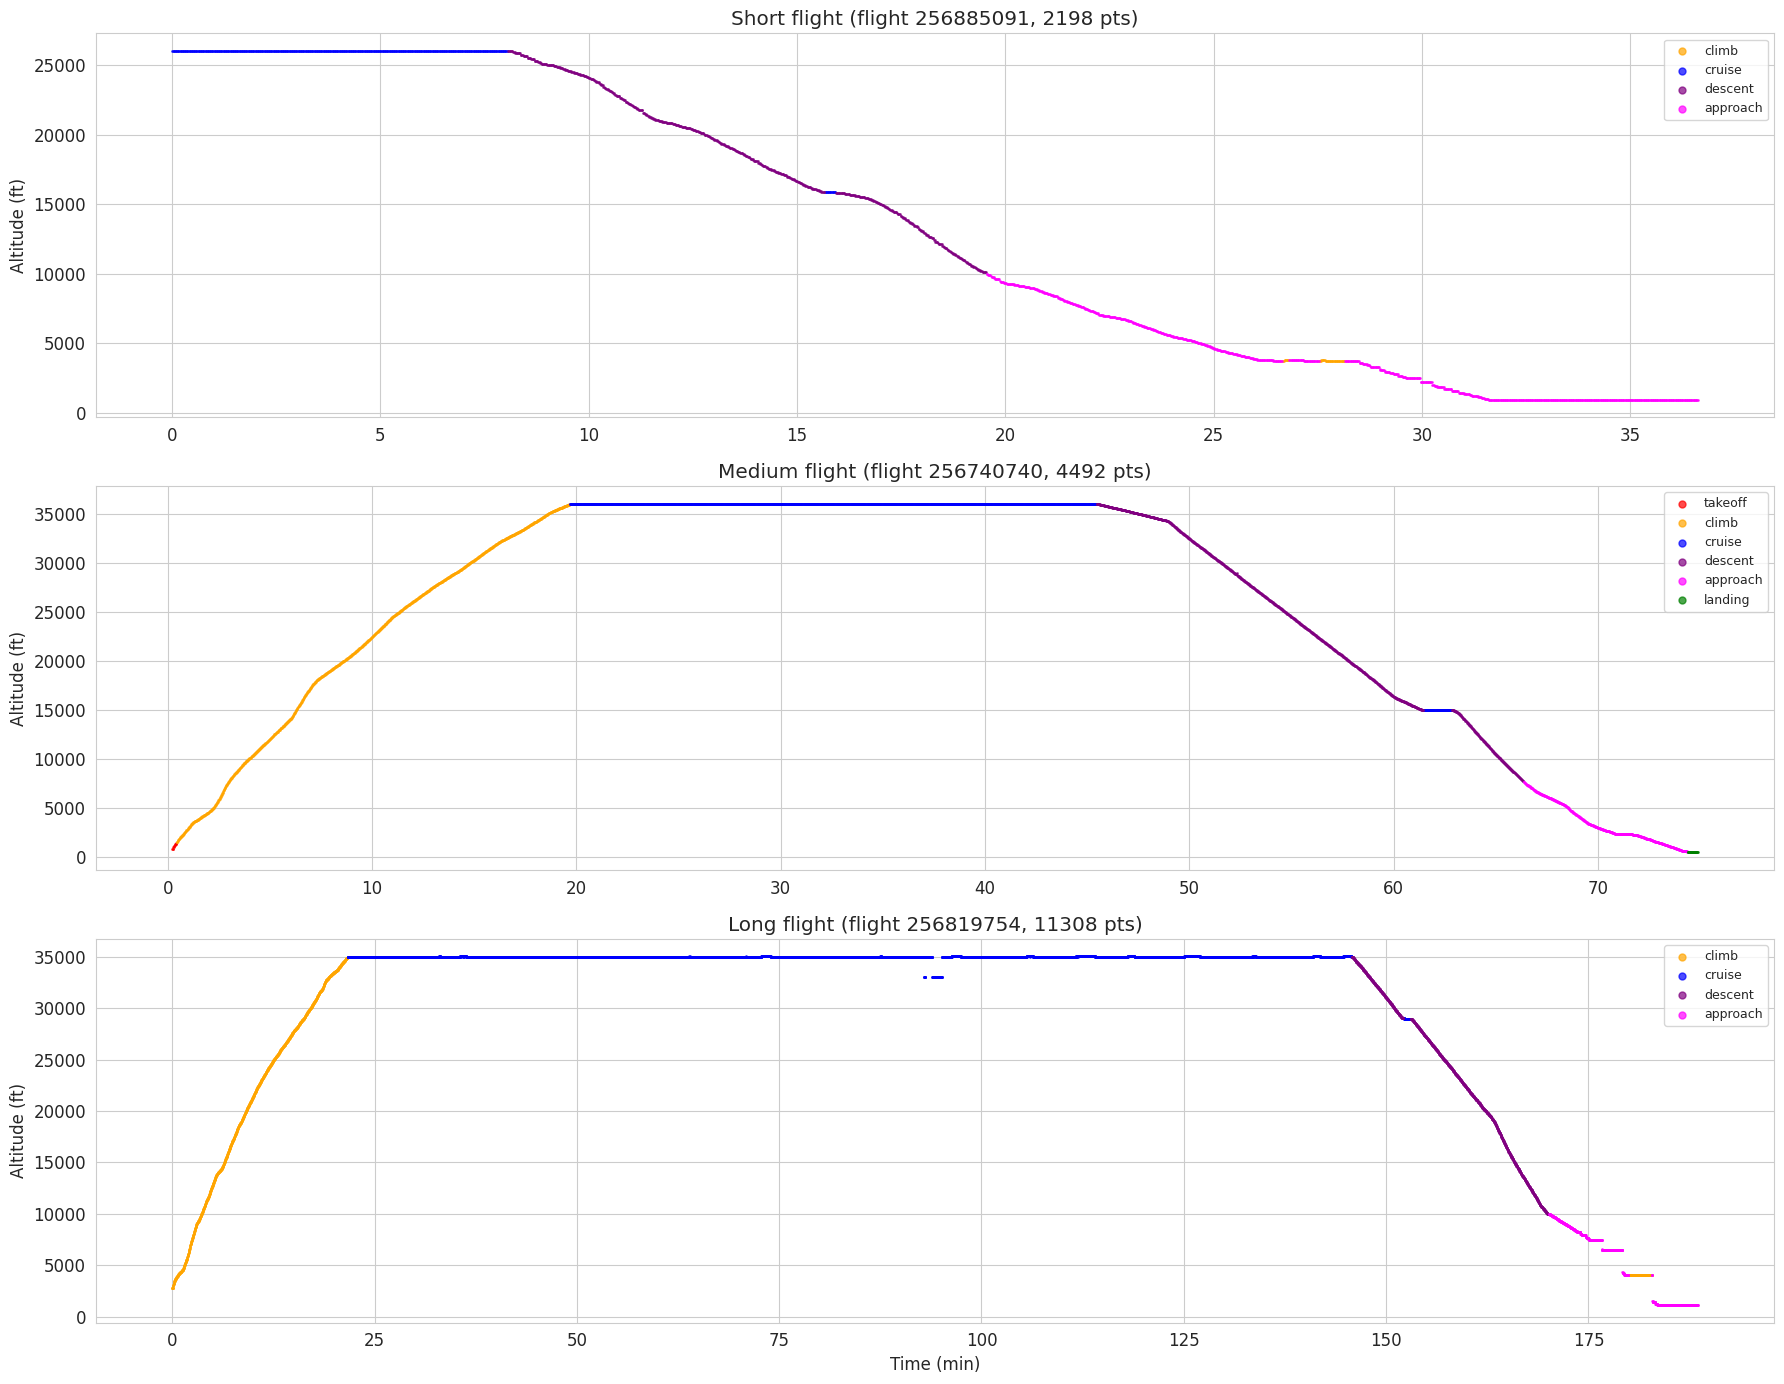

In [14]:
# === Phase segmentation на 3 рейсах ===
phase_colors = {-1: 'lightgray', 0: 'gray', 1: 'red', 2: 'orange', 3: 'blue',
                4: 'purple', 5: 'magenta', 6: 'green'}
PHASE_NAMES_PLOT = {0: 'ground', 1: 'takeoff', 2: 'climb', 3: 'cruise',
                    4: 'descent', 5: 'approach', 6: 'landing'}

# Размеры рейсов из sample
flight_sizes_in_sample = sample_full.groupby('flight_id').size()

short_pool = flight_sizes_in_sample[(flight_sizes_in_sample > 1000) & (flight_sizes_in_sample < 2500)]
medium_pool = flight_sizes_in_sample[(flight_sizes_in_sample > 4000) & (flight_sizes_in_sample < 7000)]
long_pool = flight_sizes_in_sample[flight_sizes_in_sample > 10000]

def _pick_or_load(pool, lo, hi):
    """Выбираем рейс из sample, если есть. Иначе подгружаем дополнительно."""
    if len(pool) > 0:
        chosen_fid = pool.sample(1, random_state=RANDOM_STATE).index[0]
        return chosen_fid, sample_full[sample_full['flight_id'] == chosen_fid].sort_values('timestamp')
    fid_lengths = pq.read_table(OUTPUT_PATH, columns=['flight_id']).to_pandas().groupby('flight_id').size()
    pool_extra = fid_lengths[(fid_lengths > lo) & (fid_lengths < hi)]
    chosen_fid = pool_extra.sample(1, random_state=RANDOM_STATE).index[0]
    extra = pq.read_table(
        OUTPUT_PATH, columns=viz_cols,
        filters=[('flight_id', '=', chosen_fid)]
    ).to_pandas()
    extra['timestamp'] = pd.to_datetime(extra['timestamp'])
    return chosen_fid, extra.sort_values('timestamp')

short_fid, short_data = _pick_or_load(short_pool, 1000, 2500)
medium_fid, medium_data = _pick_or_load(medium_pool, 4000, 7000)
long_fid, long_data = _pick_or_load(long_pool, 10000, 999999)

fig, axes = plt.subplots(3, 1, figsize=(18, 14))
for ax, fdata, label in zip(
    axes,
    [short_data, medium_data, long_data],
    ['Short flight', 'Medium flight', 'Long flight'],
):
    fid = fdata['flight_id'].iloc[0]
    t_min = (fdata['timestamp'] - fdata['timestamp'].min()).dt.total_seconds() / 60
    for pc, pn in PHASE_NAMES_PLOT.items():
        m = fdata['flight_phase'] == pc
        if m.any():
            ax.scatter(t_min[m], fdata.loc[m, 'altitude'], s=1, c=phase_colors[pc],
                       label=pn, alpha=0.7)
    ax.set_ylabel('Altitude (ft)')
    ax.set_title(f'{label} (flight {fid}, {len(fdata)} pts)')
    ax.legend(loc='upper right', markerscale=5, fontsize=9)
axes[-1].set_xlabel('Time (min)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'phase_segmentation_v4.png'), dpi=150,
            bbox_inches='tight')
plt.show()

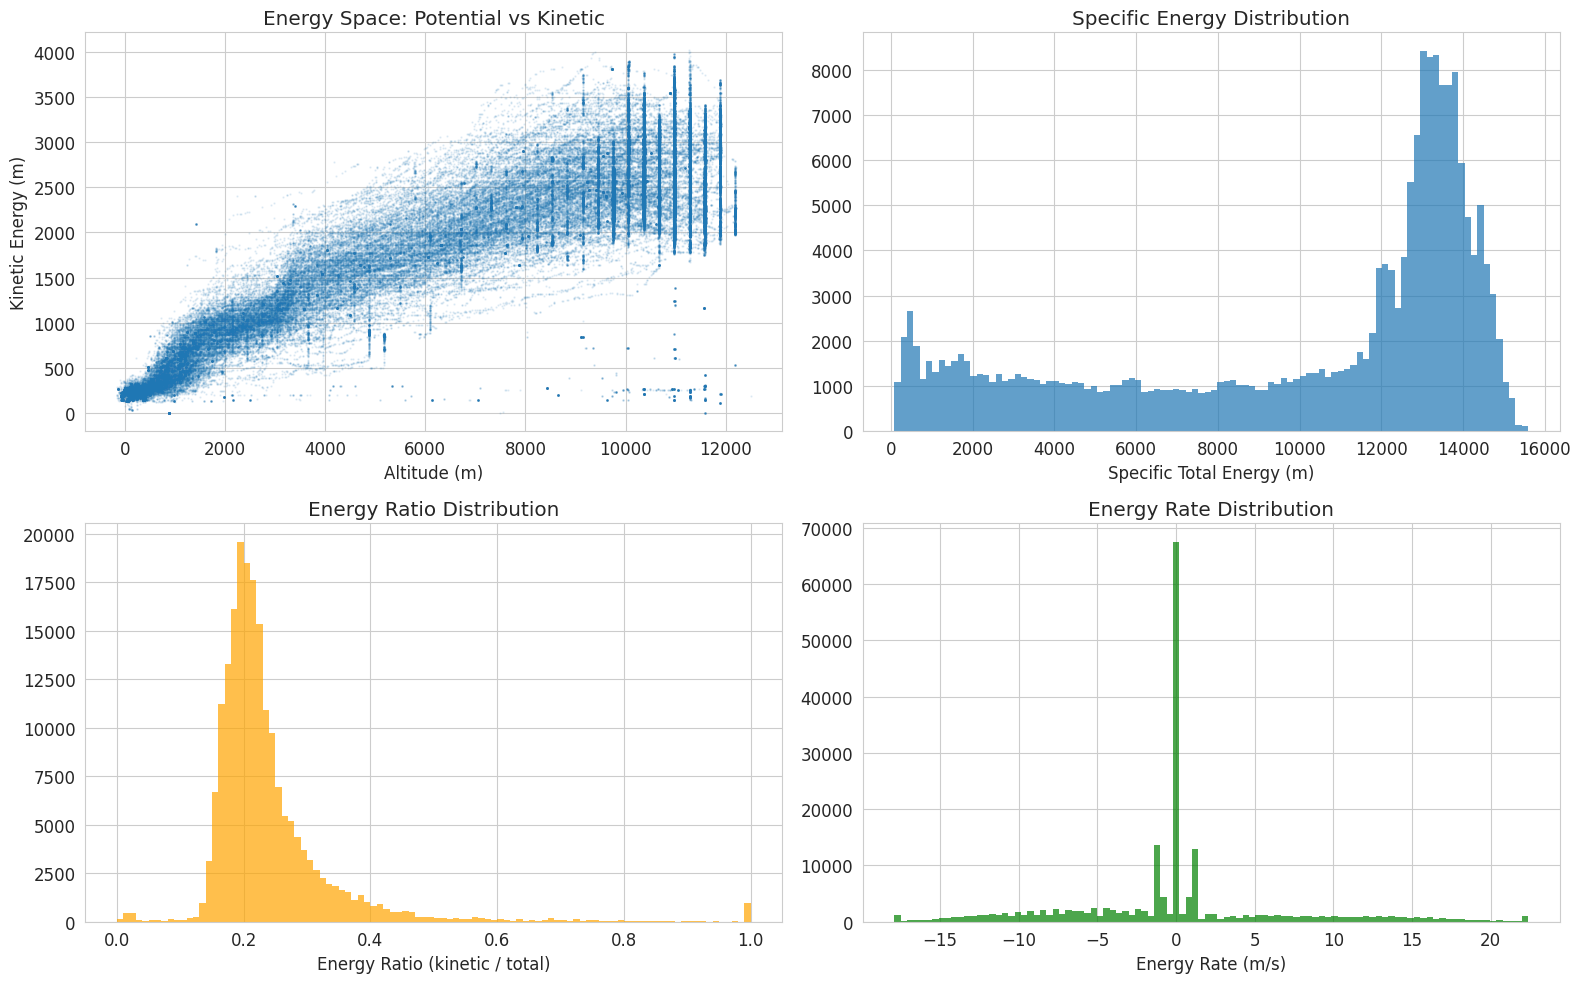

In [15]:
# === Energy metrics 4-panel ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].scatter(sample['altitude'] * FT_TO_M, sample['kinetic_energy'],
                   s=0.5, alpha=0.1)
axes[0, 0].set_xlabel('Altitude (m)')
axes[0, 0].set_ylabel('Kinetic Energy (m)')
axes[0, 0].set_title('Energy Space: Potential vs Kinetic')

axes[0, 1].hist(sample['specific_energy'].dropna(), bins=100, edgecolor='none',
                alpha=0.7)
axes[0, 1].set_xlabel('Specific Total Energy (m)')
axes[0, 1].set_title('Specific Energy Distribution')

axes[1, 0].hist(sample['energy_ratio'].clip(0, 1).dropna(), bins=100,
                edgecolor='none', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Energy Ratio (kinetic / total)')
axes[1, 0].set_title('Energy Ratio Distribution')

er = sample['energy_rate'].dropna()
if len(er) > 0:
    lo, hi = er.quantile(0.005), er.quantile(0.995)
    axes[1, 1].hist(er.clip(lo, hi), bins=100, edgecolor='none', alpha=0.7,
                    color='green')
axes[1, 1].set_xlabel('Energy Rate (m/s)')
axes[1, 1].set_title('Energy Rate Distribution')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'energy_metrics_v4.png'), dpi=150,
            bbox_inches='tight')
plt.show()

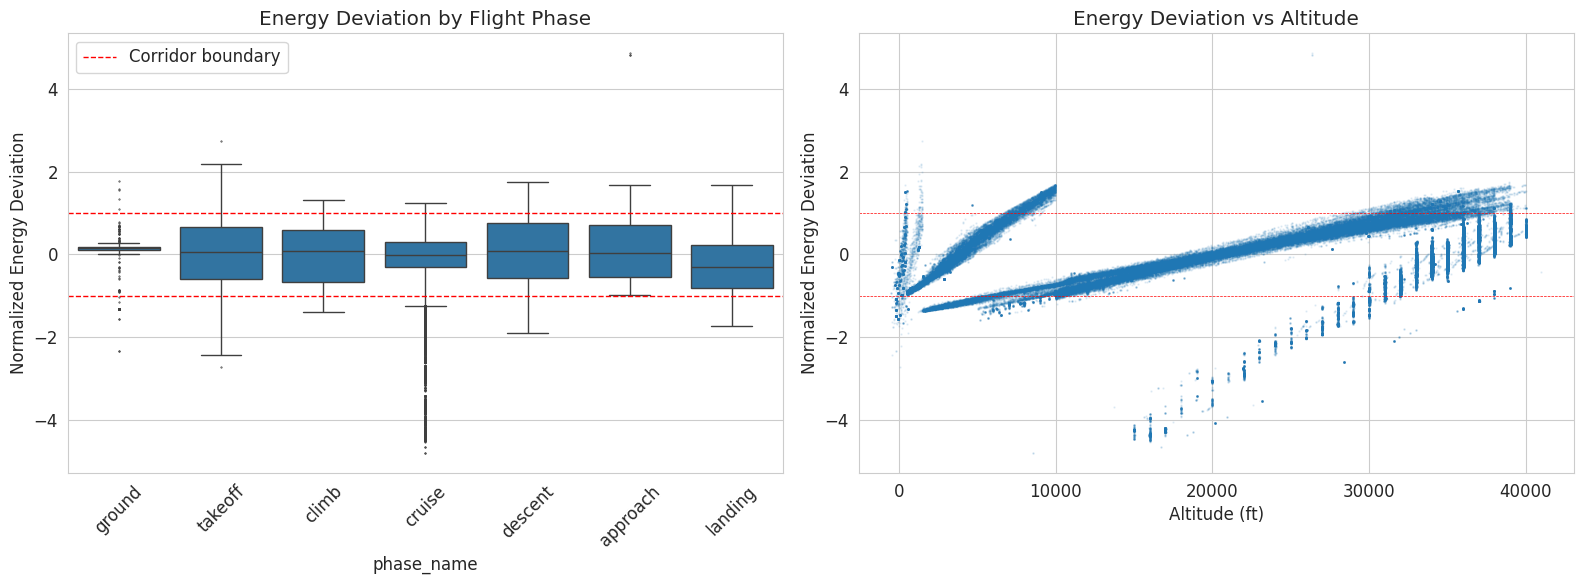

In [16]:
# === Energy deviation by phase + scatter ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

phase_order = ['ground', 'takeoff', 'climb', 'cruise', 'descent', 'approach', 'landing']
plot_data = sample[['flight_phase', 'energy_deviation']].dropna().copy()
plot_data['phase_name'] = plot_data['flight_phase'].map(PHASE_NAMES_PLOT)
plot_data = plot_data[plot_data['energy_deviation'].between(-5, 5)]

sns.boxplot(data=plot_data, x='phase_name', y='energy_deviation',
            order=phase_order, ax=axes[0], fliersize=0.5)
axes[0].axhline(1, color='red', ls='--', lw=1, label='Corridor boundary')
axes[0].axhline(-1, color='red', ls='--', lw=1)
axes[0].set_title('Energy Deviation by Flight Phase')
axes[0].set_ylabel('Normalized Energy Deviation')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

scatter_data = sample[['altitude', 'energy_deviation']].dropna()
scatter_data = scatter_data[scatter_data['energy_deviation'].between(-5, 5)]
axes[1].scatter(scatter_data['altitude'], scatter_data['energy_deviation'],
                s=0.5, alpha=0.1)
axes[1].axhline(1, color='red', ls='--', lw=0.5)
axes[1].axhline(-1, color='red', ls='--', lw=0.5)
axes[1].set_xlabel('Altitude (ft)')
axes[1].set_ylabel('Normalized Energy Deviation')
axes[1].set_title('Energy Deviation vs Altitude')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'energy_deviation_v4.png'), dpi=150,
            bbox_inches='tight')
plt.show()

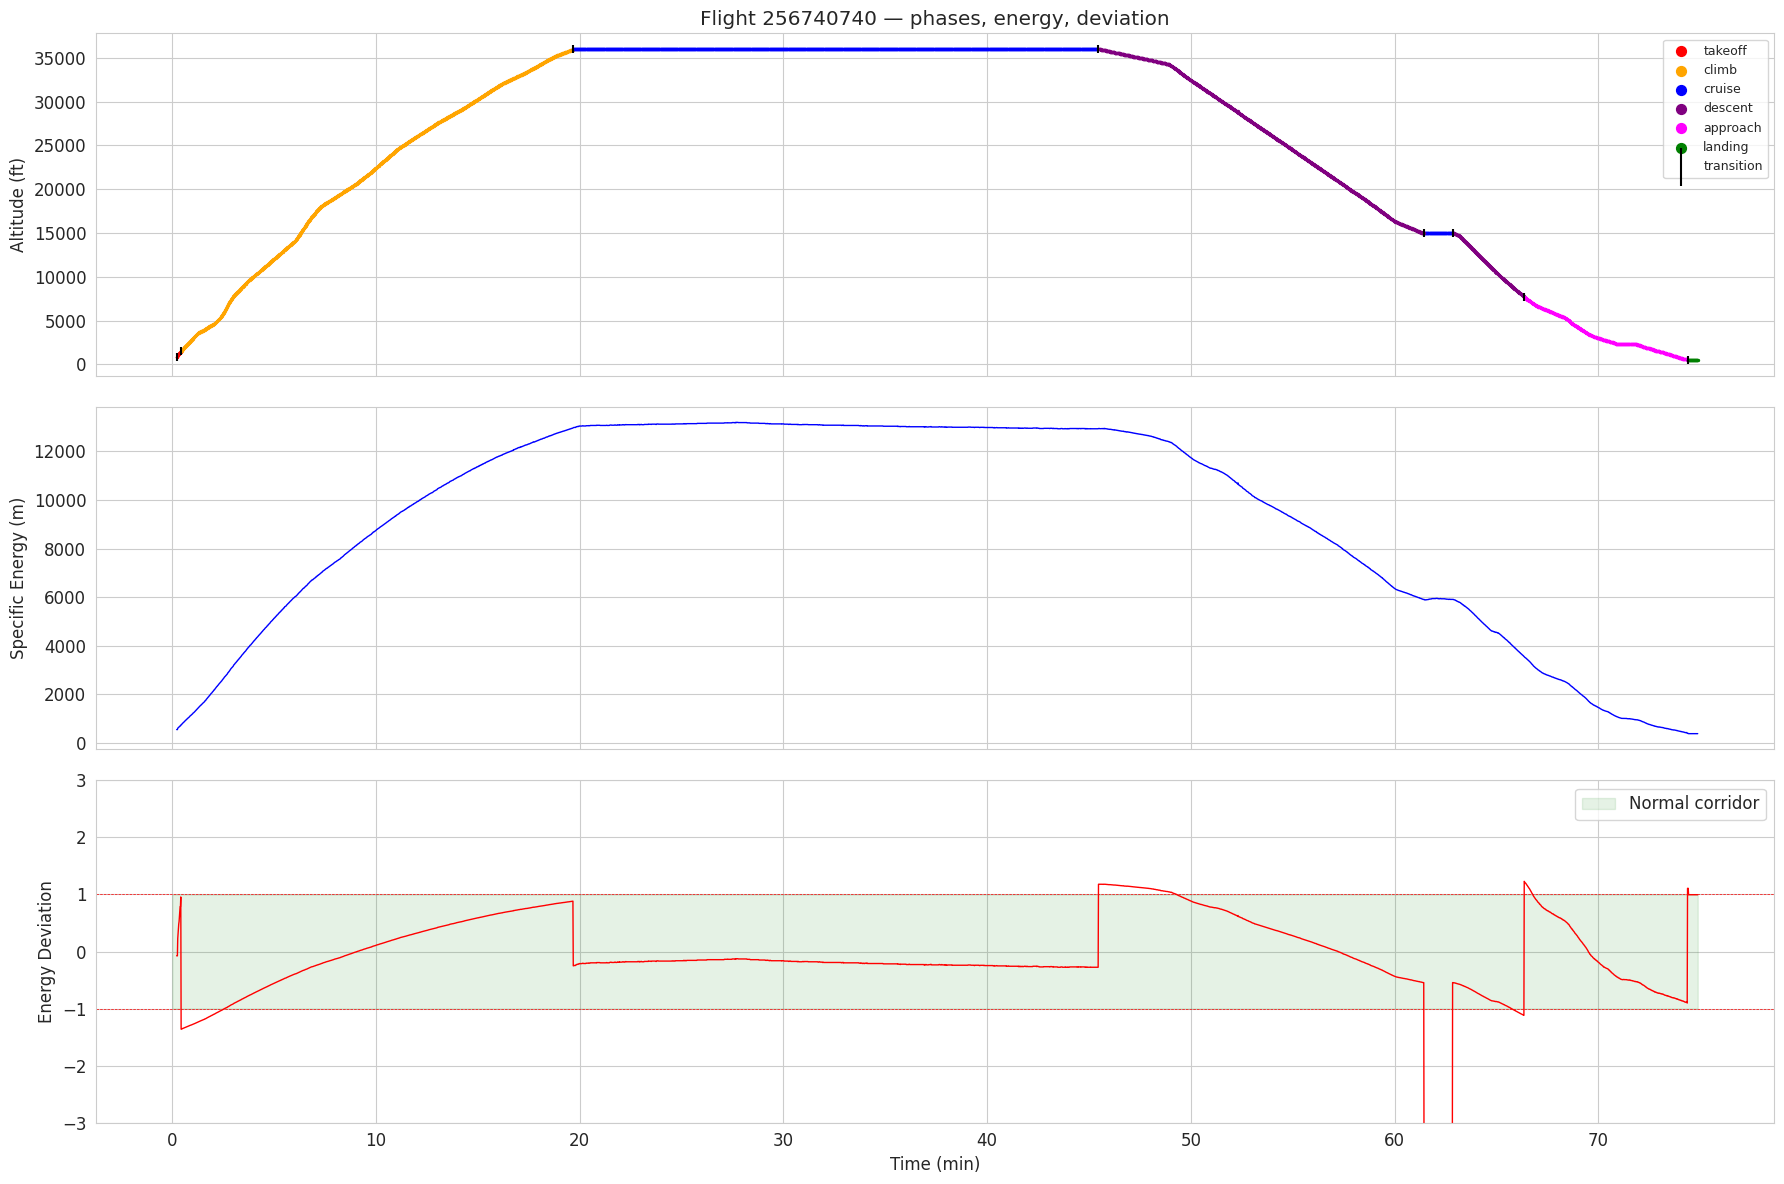

In [17]:
# === Single flight case study (используем medium_data из выше) ===
fdata = medium_data
t_min = (fdata['timestamp'] - fdata['timestamp'].min()).dt.total_seconds() / 60

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

for pc, pn in PHASE_NAMES_PLOT.items():
    m = fdata['flight_phase'] == pc
    if m.any():
        axes[0].scatter(t_min[m], fdata.loc[m, 'altitude'], s=2,
                        c=phase_colors[pc], label=pn)
trans_mask = fdata['phase_transition'] == 1
if trans_mask.any():
    axes[0].scatter(t_min[trans_mask], fdata.loc[trans_mask, 'altitude'],
                    s=30, marker='|', color='black', label='transition', zorder=10)
axes[0].set_ylabel('Altitude (ft)')
axes[0].set_title(f'Flight {medium_fid} — phases, energy, deviation')
axes[0].legend(loc='upper right', markerscale=5, fontsize=9)

axes[1].plot(t_min, fdata['specific_energy'], lw=1, color='blue')
axes[1].set_ylabel('Specific Energy (m)')

axes[2].fill_between(t_min, -1, 1, alpha=0.1, color='green', label='Normal corridor')
axes[2].plot(t_min, fdata['energy_deviation'], lw=1, color='red')
axes[2].axhline(1, color='red', ls='--', lw=0.5)
axes[2].axhline(-1, color='red', ls='--', lw=0.5)
axes[2].set_ylabel('Energy Deviation')
axes[2].set_xlabel('Time (min)')
axes[2].set_ylim(-3, 3)
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'flight_energy_corridor_v4.png'), dpi=150,
            bbox_inches='tight')
plt.show()

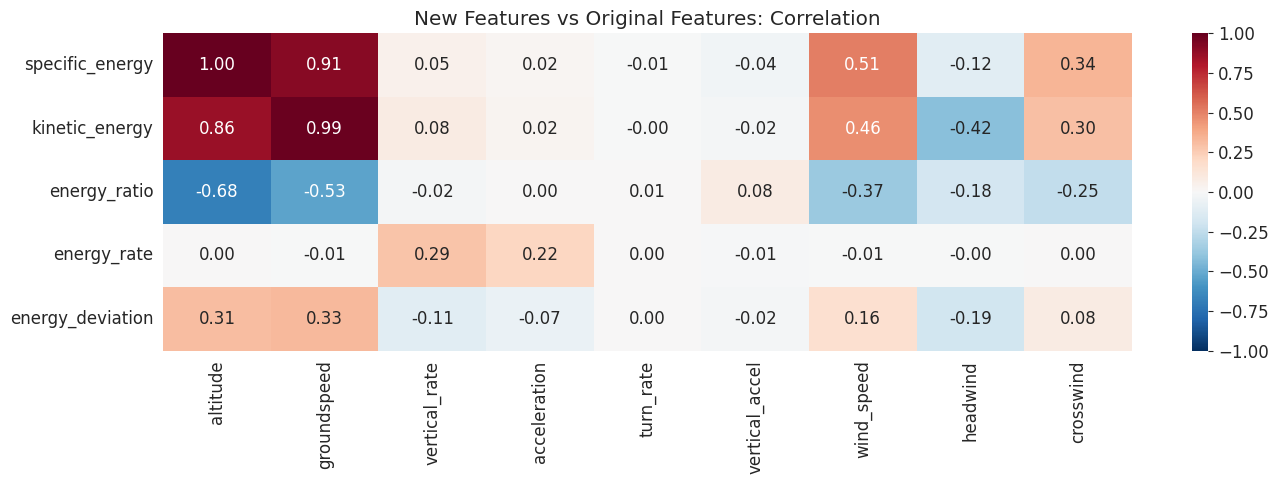

21805

In [18]:
# === Correlation heatmap (new vs old) ===
new_cols = ['specific_energy', 'kinetic_energy', 'energy_ratio',
            'energy_rate', 'energy_deviation']
old_cols = ['altitude', 'groundspeed', 'vertical_rate',
            'acceleration', 'turn_rate', 'vertical_accel',
            'wind_speed', 'headwind', 'crosswind']
corr = sample[old_cols + new_cols].corr().loc[new_cols, old_cols]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax)
ax.set_title('New Features vs Original Features: Correlation')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'new_features_corr_v4.png'), dpi=150,
            bbox_inches='tight')
plt.show()

del sample, sample_full
gc.collect()

## 9. Model contract: MODEL_FEATURES_V3 / DIAGNOSTIC_COLUMNS_V3

Явное объявление контракта между 02b и 03_models. После этой ячейки
03_models должен использовать **именно эти константы** для отбора колонок,
без хардкодинга списков.

`MODEL_FEATURES_V3` — 12 признаков для всех трёх моделей (IF, HDBSCAN+GLOSH,
LSTM-AE). `DIAGNOSTIC_COLUMNS_V3` — всё остальное в датасете, доступно для
визуализации, post-hoc интерпретации top-anomalies, и dashboard.

Имя `_V3` соответствует pipeline-версии (clean_v3 → enriched_v4 → models_v3),
а не версии файла 02b. v4 — это bugfix-релиз для energy_ratio formula
в рамках V3-цепочки контракта (model feature set не изменился: те же
12 признаков).

In [12]:
MODEL_FEATURES_V3 = [
    # 6 кинематических
    'altitude', 'groundspeed', 'vertical_rate',
    'acceleration', 'turn_rate', 'vertical_accel',
    # 3 ветровых
    'wind_speed', 'headwind', 'crosswind',
    # 3 энергетических
    'energy_ratio', 'energy_rate', 'energy_deviation',
]

DIAGNOSTIC_COLUMNS_V3 = [
    # Diagnostic energy (дублируют altitude/groundspeed)
    'specific_energy', 'kinetic_energy',
    # Phase
    'flight_phase', 'phase_transition',
    # Phase z-scores (доступны для per-phase анализа, не идут в модель)
    'altitude_phase_z', 'groundspeed_phase_z', 'vertical_rate_phase_z',
    'specific_energy_phase_z', 'energy_rate_phase_z',
    # DQ flags из 02_preprocessing_v3
    *DQ_FLAGS_V3,
]

assert len(MODEL_FEATURES_V3) == 12, f'Expected 12 model features, got {len(MODEL_FEATURES_V3)}'
assert len(DIAGNOSTIC_COLUMNS_V3) == 16, f'Expected 16 diagnostic columns, got {len(DIAGNOSTIC_COLUMNS_V3)}'

print(f'MODEL_FEATURES_V3 ({len(MODEL_FEATURES_V3)}):')
for f in MODEL_FEATURES_V3:
    print(f'  {f}')

print(f'\nDIAGNOSTIC_COLUMNS_V3 ({len(DIAGNOSTIC_COLUMNS_V3)}):')
for f in DIAGNOSTIC_COLUMNS_V3:
    print(f'  {f}')

# Verify all model + diagnostic columns are present in the parquet file
metadata_cols = ['flight_id', 'timestamp', 'latitude', 'longitude', 'icao24']
expected_total = set(metadata_cols + MODEL_FEATURES_V3 + DIAGNOSTIC_COLUMNS_V3)
actual_cols = set(pq.ParquetFile(OUTPUT_PATH).schema.names)

missing_cols = expected_total - actual_cols
extra_cols = actual_cols - expected_total

print(f'\nSchema contract check:')
print(f'  Expected: {len(expected_total)} columns')
print(f'  Actual:   {len(actual_cols)} columns')
print(f'  Missing:  {missing_cols if missing_cols else "none"}')
print(f'  Extra:    {extra_cols if extra_cols else "none"}')

assert not missing_cols, f'Schema mismatch: missing {missing_cols}'
assert not extra_cols, f'Schema mismatch: extra {extra_cols}'
print('Schema contract holds.')

final_pf = pq.ParquetFile(OUTPUT_PATH)
n_unique_flights_final = len(np.unique(
    pq.read_table(OUTPUT_PATH, columns=['flight_id']).column('flight_id').to_numpy()
))
print(f'\nFinal: {OUTPUT_PATH}')
print(f'Rows: {final_pf.metadata.num_rows:,}, Flights: {n_unique_flights_final}')
print(f'Columns: {len(actual_cols)}, Size: {os.path.getsize(OUTPUT_PATH) / 1e9:.2f} GB')
print('02b_v4 complete. Ready for 02c.')

MODEL_FEATURES_V3 (12):
  altitude
  groundspeed
  vertical_rate
  acceleration
  turn_rate
  vertical_accel
  wind_speed
  headwind
  crosswind
  energy_ratio
  energy_rate
  energy_deviation

DIAGNOSTIC_COLUMNS_V3 (16):
  specific_energy
  kinetic_energy
  flight_phase
  phase_transition
  altitude_phase_z
  groundspeed_phase_z
  vertical_rate_phase_z
  specific_energy_phase_z
  energy_rate_phase_z
  altitude_threshold_bad
  groundspeed_threshold_bad
  vertical_rate_threshold_bad
  altitude_spike_corrected
  groundspeed_spike_corrected
  vertical_rate_spike_corrected
  stale_altitude

Schema contract check:
  Expected: 33 columns
  Actual:   33 columns
  Missing:  none
  Extra:    none
Schema contract holds.

Final: /content/drive/MyDrive/thesis_processed/european_flights_enriched_v4.parquet
Rows: 149,129,454, Flights: 29788
Columns: 33, Size: 8.36 GB
02b_v4 complete. Ready for 02c.
